In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sb
import time

In [2]:
np.random.seed(42)

In [3]:
df = pd.read_csv("dataset/mnist_train.csv")
print(df.isna().sum().sum())
df

0


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
X_raw = df.drop("label",axis=1).to_numpy()

X = X_raw / 255.0 

In [5]:
Y_raw = df["label"].to_numpy()

number_of_classes = 10
Y = np.eye(number_of_classes)[Y_raw] # One-hot encoding 

In [6]:
class multilayer_perceptron:
    def __init__(self, layer_neurons, activations, learning_rate, epochs, batch_size, keep_prob=0.8, print_logs=False):
        self.layers_n = layer_neurons
        
        # for loaded model
        if activations[-1] != 'softmax':
            self.activations = activations + ['softmax']
        else:
            self.activations = activations
            
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.keep_prob = keep_prob
        self.print_logs = print_logs

        self.results = []
        self.val_results = []       
        self.accuracy = []
        self.val_accuracy = []

        # Initialize Weights and Biases
        self.W = []
        self.b = []
        for i in range(len(layer_neurons)-1):
            n_in = layer_neurons[i]
            n_out = layer_neurons[i+1]
            
            if self.activations[i] == 'relu':
                scale = np.sqrt(2.0 / n_in)  # He Initialization
            else:
                scale = np.sqrt(1.0 / n_in)  # Xavier/Glorot Initialization
                
            self.W.append(np.random.randn(n_in, n_out) * scale)
            self.b.append(np.zeros((1, n_out)))
        
        self.activation_funcs = {'relu': self.ReLU, 'tanh': self.tanh, 'softmax': self.softmax}
        self.activation_derivatives = {'relu': self.ReLU_derivative, 'tanh': self.tanh_derivative}

    # --- Activation Functions ---
    def ReLU(self, X): 
        return np.maximum(0, X)
    
    def ReLU_derivative(self, Z): 
        return (Z > 0) * 1.0

    def tanh(self, X):
        a = np.exp(np.clip(X, -500, 500))
        b = np.exp(-np.clip(X, -500, 500))
        return (a - b) / (a + b)

    def tanh_derivative(self, Z): 
        A_clean = self.tanh(Z)
        return 1.0 - A_clean**2 

    def softmax(self, X):
        row_maxes = np.max(X, axis=1, keepdims=True)
        shifted_X = X - row_maxes
        exp_X = np.exp(shifted_X)
        return exp_X / np.sum(exp_X, axis=1, keepdims=True)

    # --- Forward Propagation ---
    def feed_forward(self, X, training=False):
        self.A = [X]
        self.Z = []
        self.masks = []  
        
        for i in range(len(self.W)):
            z = np.dot(self.A[i], self.W[i]) + self.b[i]
            self.Z.append(z)
            a = self.activation_funcs[self.activations[i]](z)
            
            if training and i < len(self.W) - 1:
                mask = (np.random.rand(*a.shape) < self.keep_prob)
                a = (a * mask) / self.keep_prob
                self.masks.append(mask)
            else:
                self.masks.append(None)
                
            self.A.append(a)
            
        return self.A[-1]

    def _backpropagate(self, Y):
        total_samples = Y.shape[0]
        
        dW = [None] * len(self.W)
        db = [None] * len(self.b)
        
        # 1. Output error calculation
        dZ = self.A[-1] - Y
        
        # 2. Backward loop to calculate gradients
        for i in reversed(range(len(self.W))):
            dW[i] = np.dot(self.A[i].T, dZ) / total_samples
            db[i] = np.sum(dZ, axis=0, keepdims=True) / total_samples
            
            if i > 0:
                act_prev = self.activations[i-1]
                derivative = self.activation_derivatives[act_prev](self.Z[i-1])
                
                dZ = np.dot(dZ, self.W[i].T) * derivative
                
                if self.masks[i-1] is not None:
                    dZ = (dZ * self.masks[i-1]) / self.keep_prob
        
        for i in range(len(self.W)):
            self.W[i] -= self.lr * dW[i]
            self.b[i] -= self.lr * db[i]
    
    def compute_loss(self, Y_pred, Y_true):
        epsilon = 1e-15
        Y_pred = np.clip(Y_pred, epsilon, 1 - epsilon)
        return -np.sum(Y_true * np.log(Y_pred)) / Y_true.shape[0]

    def save_model(self, filename="fully_trained_mlp"):    
        if not filename.endswith('.npz'):
            filename = filename + ".npz"

        config = np.array([
            self.lr,
            self.batch_size,
            self.keep_prob
        ])
        
        b_container = np.empty(len(self.b), dtype=object)
        for idx, bias in enumerate(self.b):
            b_container[idx] = bias

        np.savez_compressed(
            filename, 
            layers_n=np.array(self.layers_n),
            activations=np.array(self.activations),
            config=config,
            b=b_container, 
            *self.W  
        )
        print(f"saved the model in {filename}")

    @staticmethod
    def load_model(filename="fully_trained_mlp.npz"):
        if not filename.endswith('.npz'):
            filename = filename + ".npz"

        with np.load(filename, allow_pickle=True) as data:
            layers_n = data['layers_n'].tolist()
            activations = data['activations'].tolist()
            config = data['config']
            
            model = multilayer_perceptron(
                layer_neurons=layers_n,
                activations=activations,
                learning_rate=float(config[0]),
                epochs=10,
                batch_size=int(config[1]),
                keep_prob=float(config[2])
            )
            
            num_layers = len(layers_n) - 1
            model.W = [data[f'arr_{i}'] for i in range(num_layers)]
            model.b = list(data['b'])
        
        return model

    def fit(self, X, Y, X_val, Y_val, patience=3):
        total_samples = Y.shape[0]
        indices = np.arange(total_samples)

        best_val_loss = float('inf')
        patience_counter = 0
        
        for ep in range(self.epochs):
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]

            for i in range(0, total_samples, self.batch_size):
                X_batch = X_shuffled[i : i + self.batch_size]
                Y_batch = Y_shuffled[i : i + self.batch_size]
                
                self.feed_forward(X_batch, training=True)
                self._backpropagate(Y_batch)            

            full_train_pred = self.feed_forward(X, training=False)
            train_loss = self.compute_loss(full_train_pred, Y)
            train_acc = np.mean(np.argmax(full_train_pred, axis=1) == np.argmax(Y, axis=1)) * 100
            
            self.results.append(train_loss)
            self.accuracy.append(train_acc)

            val_loss, val_acc = 0.0, 0.0
            if len(Y_val) > 0:
                full_val_pred = self.feed_forward(X_val, training=False)
                val_loss = self.compute_loss(full_val_pred, Y_val)
                val_acc = np.mean(np.argmax(full_val_pred, axis=1) == np.argmax(Y_val, axis=1)) * 100

                self.val_results.append(val_loss)
                self.val_accuracy.append(val_acc)

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0 
                else:
                    patience_counter += 1
                    
                if patience_counter >= patience:
                    print(f"\n[Early Stopping] Validation loss has stalled for {patience} epochs. Stopping training safely to prevent overfitting.")
                    break
            
            if self.print_logs:
                print(f"Epoch {ep+1:02d}/{self.epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

In [7]:

total_samples = X.shape[0]
split_index = int(total_samples * 0.8) 

indices = np.arange(total_samples)
np.random.shuffle(indices)

X_train, X_val = X[indices[:split_index]], X[indices[split_index:]]
Y_train, Y_val = Y[indices[:split_index]], Y[indices[split_index:]]

1-Layer Network (Batch=16) Complete in: 125.95 seconds
1-Layer Network (Batch=128) Complete in: 29.15 seconds
1-Layer Network (Batch=1024) Complete in: 17.78 seconds


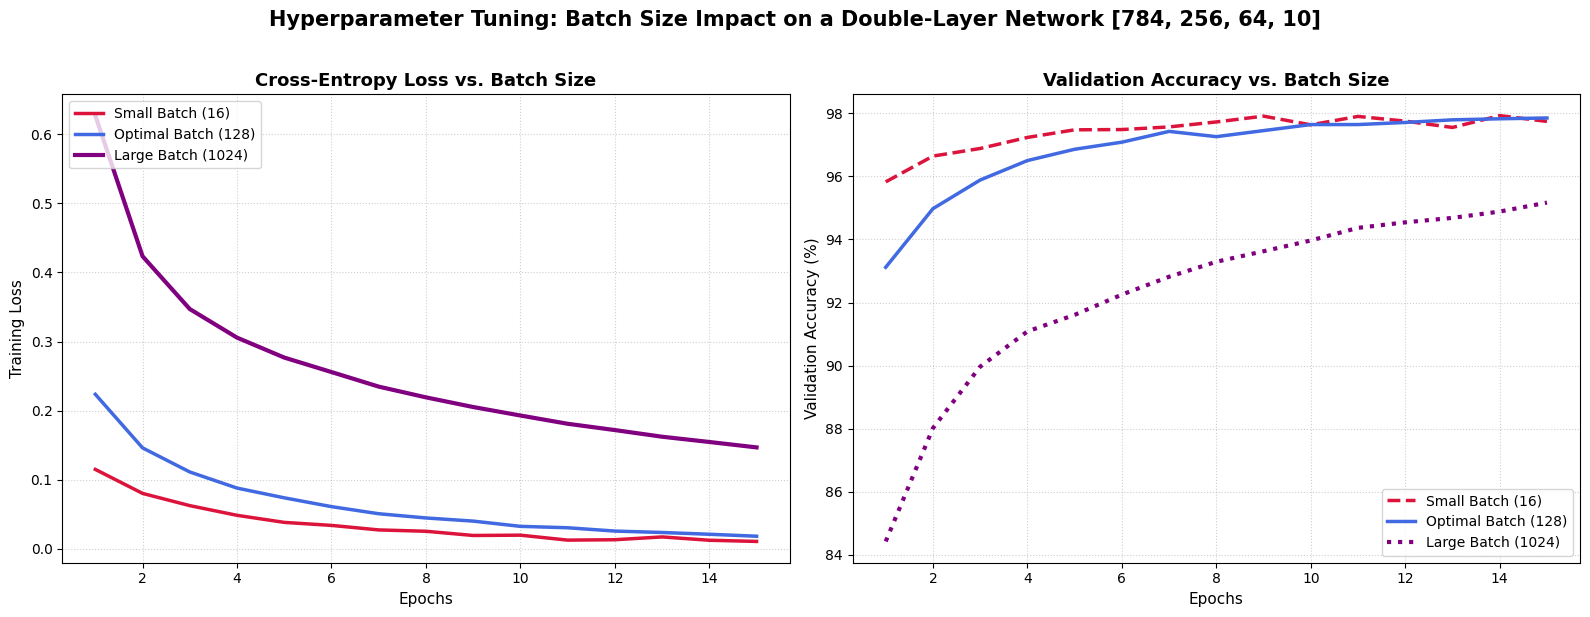

In [8]:
learning_rate = 0.15    
epochs = 15            
patience_val = 15      

batch_small = 16
batch_med   = 128
batch_large = 1024

arch_1_layer = [784, 256, 64,  10]
activations_1_layer = ['relu', 'tanh'] 

epochs_range = range(1, epochs + 1)

# -------------------------------------------------------------
# 1. SMALL BATCH SIZE TRAINING (Batch = 16)
# -------------------------------------------------------------
start_time = time.time()
mlp_small = multilayer_perceptron(arch_1_layer, activations_1_layer, learning_rate, epochs, batch_small)
mlp_small.fit(X_train, Y_train, X_val, Y_val, patience=patience_val)
time_batch_small = time.time() - start_time
print(f"1-Layer Network (Batch={batch_small}) Complete in: {time_batch_small:.2f} seconds")

# -------------------------------------------------------------
# 2. MEDIUM BATCH SIZE TRAINING (Batch = 128)
# -------------------------------------------------------------
start_time = time.time()
mlp_medium = multilayer_perceptron(arch_1_layer, activations_1_layer, learning_rate, epochs, batch_med)
mlp_medium.fit(X_train, Y_train, X_val, Y_val, patience=patience_val)
time_batch_med = time.time() - start_time
print(f"1-Layer Network (Batch={batch_med}) Complete in: {time_batch_med:.2f} seconds")

# -------------------------------------------------------------
# 3. LARGE BATCH SIZE TRAINING (Batch = 1024)
# -------------------------------------------------------------
start_time = time.time()
mlp_large = multilayer_perceptron(arch_1_layer, activations_1_layer, learning_rate, epochs, batch_large)
mlp_large.fit(X_train, Y_train, X_val, Y_val, patience=patience_val)
time_batch_large = time.time() - start_time
print(f"1-Layer Network (Batch={batch_large}) Complete in: {time_batch_large:.2f} seconds")


# =============================================================
# PLOTS
# =============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Cross-Entropy Training Loss ---
ax1.plot(epochs_range, mlp_small.results, color='crimson', linestyle='-', linewidth=2.5, label=f'Small Batch ({batch_small})')
ax1.plot(epochs_range, mlp_medium.results, color='royalblue', linestyle='-', linewidth=2.5, label=f'Optimal Batch ({batch_med})')
ax1.plot(epochs_range, mlp_large.results, color='purple', linestyle='-', linewidth=3, label=f'Large Batch ({batch_large})')

ax1.set_title('Cross-Entropy Loss vs. Batch Size', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Training Loss', fontsize=11)
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: Validation Accuracy ---
ax2.plot(epochs_range, mlp_small.val_accuracy, color='crimson', linestyle='--', linewidth=2.5, label=f'Small Batch ({batch_small})')
ax2.plot(epochs_range, mlp_medium.val_accuracy, color='royalblue', linestyle='-', linewidth=2.5, label=f'Optimal Batch ({batch_med})')
ax2.plot(epochs_range, mlp_large.val_accuracy, color='purple', linestyle=':', linewidth=3, label=f'Large Batch ({batch_large})')

ax2.set_title('Validation Accuracy vs. Batch Size', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=11)
ax2.set_ylabel('Validation Accuracy (%)', fontsize=11)
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Hyperparameter Tuning: Batch Size Impact on a Double-Layer Network [784, 256, 64, 10]', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

1-Layer Network (LR=0.01) Complete in: 29.77 seconds
1-Layer Network (LR=0.2) Complete in: 29.21 seconds
1-Layer Network (LR=1.1) Complete in: 29.25 seconds


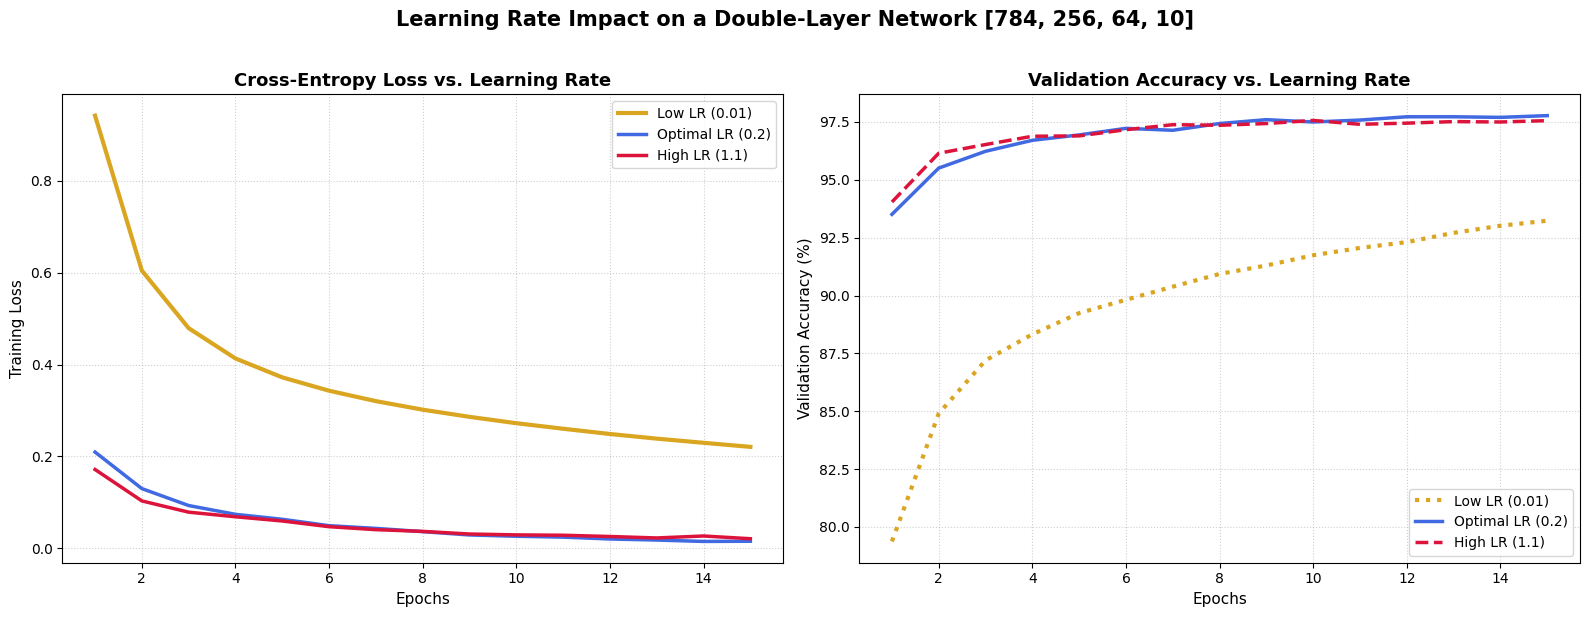

In [9]:
batch_size = 128
epochs = 15            
patience_val = 15

lr_low = 0.01
lr_med = 0.2
lr_high = 1.1

arch_1_layer = [784, 256, 64, 10]
activations_1_layer = ['relu', 'tanh'] 

epochs_range = range(1, epochs + 1)

# -------------------------------------------------------------
# 1. LOW LEARNING RATE TRAINING (LR = 0.01)
# -------------------------------------------------------------
start_time = time.time()
mlp_small = multilayer_perceptron(arch_1_layer, activations_1_layer, lr_low, epochs, batch_size)
mlp_small.fit(X_train, Y_train, X_val, Y_val, patience=patience_val)
time_lr_low = time.time() - start_time
print(f"1-Layer Network (LR={lr_low}) Complete in: {time_lr_low:.2f} seconds")

# -------------------------------------------------------------
# 2. MEDIUM LEARNING RATE TRAINING (LR = 0.2)
# -------------------------------------------------------------
start_time = time.time()
mlp_medium = multilayer_perceptron(arch_1_layer, activations_1_layer, lr_med, epochs, batch_size)
mlp_medium.fit(X_train, Y_train, X_val, Y_val, patience=patience_val)
time_lr_med = time.time() - start_time
print(f"1-Layer Network (LR={lr_med}) Complete in: {time_lr_med:.2f} seconds")

# -------------------------------------------------------------
# 3. HIGH LEARNING RATE TRAINING (LR = 0.9)
# -------------------------------------------------------------
start_time = time.time()
mlp_large = multilayer_perceptron(arch_1_layer, activations_1_layer, lr_high, epochs, batch_size)
mlp_large.fit(X_train, Y_train, X_val, Y_val, patience=patience_val)
time_lr_high = time.time() - start_time
print(f"1-Layer Network (LR={lr_high}) Complete in: {time_lr_high:.2f} seconds")


# =============================================================
# PLOTS
# =============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Cross-Entropy Training Loss ---
ax1.plot(epochs_range, mlp_small.results, color='goldenrod', linestyle='-', linewidth=3, label=f'Low LR ({lr_low})')
ax1.plot(epochs_range, mlp_medium.results, color='royalblue', linestyle='-', linewidth=2.5,  label=f'Optimal LR ({lr_med})')
ax1.plot(epochs_range, mlp_large.results, color='crimson', linestyle='-', linewidth=2.5,  label=f'High LR ({lr_high})')

ax1.set_title('Cross-Entropy Loss vs. Learning Rate', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Training Loss', fontsize=11)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: Validation Accuracy ---
ax2.plot(epochs_range, mlp_small.val_accuracy, color='goldenrod', linestyle=':', linewidth=3, label=f'Low LR ({lr_low})')
ax2.plot(epochs_range, mlp_medium.val_accuracy, color='royalblue', linestyle='-', linewidth=2.5, label=f'Optimal LR ({lr_med})')
ax2.plot(epochs_range, mlp_large.val_accuracy, color='crimson', linestyle='--', linewidth=2.5, label=f'High LR ({lr_high})')

ax2.set_title('Validation Accuracy vs. Learning Rate', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=11)
ax2.set_ylabel('Validation Accuracy (%)', fontsize=11)
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Learning Rate Impact on a Double-Layer Network [784, 256, 64, 10]', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

1-Layer Architecture [784, 256, 10] Complete in: 32.30 seconds
2-Layer Architecture [784, 256, 64, 10] Complete in: 63.25 seconds


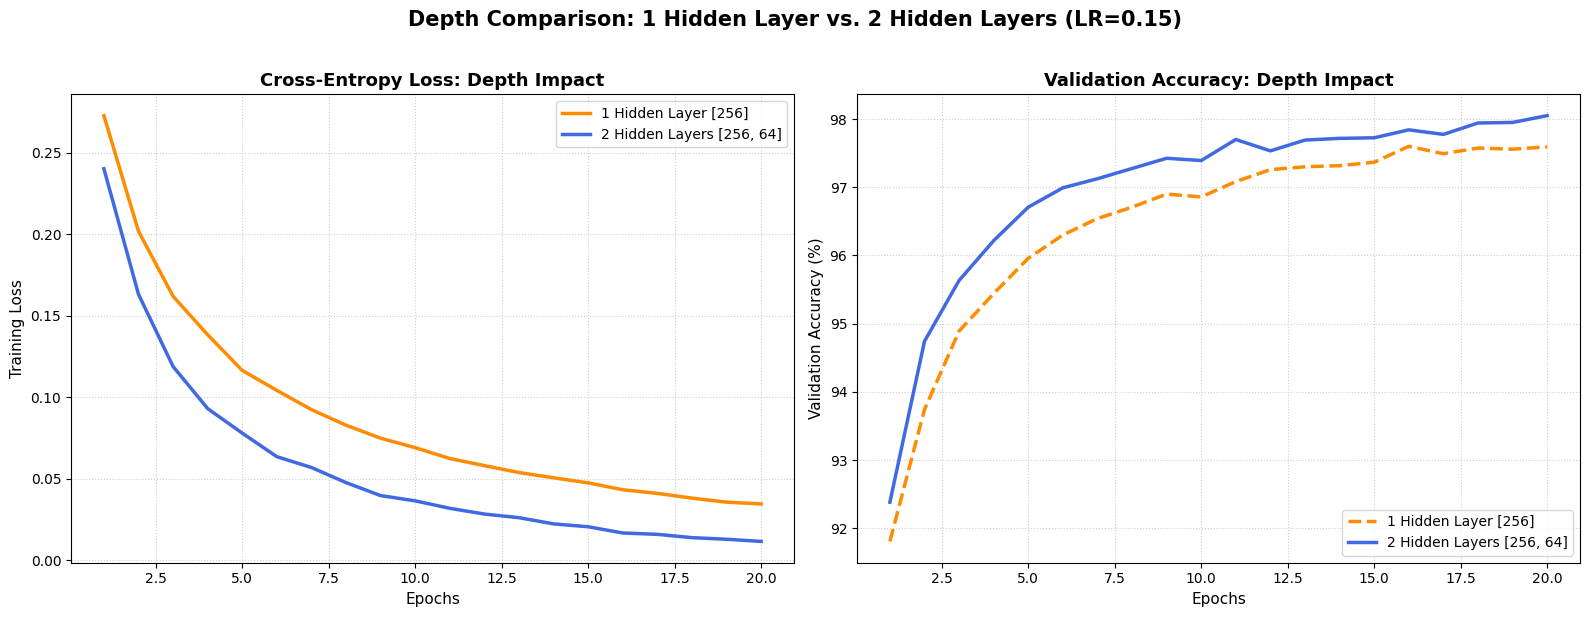

In [10]:
learning_rate = 0.15    
batch_size = 128
epochs = 20            
patience_val = 20      

arch_1_layer = [784, 256, 10]
arch_2_layer = [784, 256, 64, 10]

activations_1_layer = ['relu']          
activations_2_layer = ['relu', 'tanh']  

epochs_range = range(1, epochs + 1)

# -------------------------------------------------------------
# 1. ONE-HIDDEN-LAYER MODEL TRAINING
# -------------------------------------------------------------
start_time = time.time()
mlp_small = multilayer_perceptron(arch_1_layer, activations_1_layer, learning_rate, epochs, batch_size)
mlp_small.fit(X_train, Y_train, X_val, Y_val, patience=patience_val)
time_1l = time.time() - start_time
print(f"1-Layer Architecture [784, 256, 10] Complete in: {time_1l:.2f} seconds")

# -------------------------------------------------------------
# 2. TWO-HIDDEN-LAYER MODEL TRAINING
# -------------------------------------------------------------
start_time = time.time()
mlp_medium = multilayer_perceptron(arch_2_layer, activations_2_layer, learning_rate, epochs, batch_size)
mlp_medium.fit(X_train, Y_train, X_val, Y_val, patience=patience_val)
time_2l = time.time() - start_time
print(f"2-Layer Architecture [784, 256, 64, 10] Complete in: {time_2l:.2f} seconds")


# =============================================================
# PLOTS
# =============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Cross-Entropy Training Loss ---
ax1.plot(epochs_range, mlp_small.results, color='darkorange', linestyle='-', linewidth=2.5, label=f'1 Hidden Layer [256]')
ax1.plot(epochs_range, mlp_medium.results, color='royalblue', linestyle='-', linewidth=2.5, label=f'2 Hidden Layers [256, 64]')

ax1.set_title('Cross-Entropy Loss: Depth Impact', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Training Loss', fontsize=11)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: Validation Accuracy ---
ax2.plot(epochs_range, mlp_small.val_accuracy, color='darkorange', linestyle='--', linewidth=2.5, label=f'1 Hidden Layer [256]')
ax2.plot(epochs_range, mlp_medium.val_accuracy, color='royalblue', linestyle='-', linewidth=2.5, label=f'2 Hidden Layers [256, 64]')

ax2.set_title('Validation Accuracy: Depth Impact', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=11)
ax2.set_ylabel('Validation Accuracy (%)', fontsize=11)
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.suptitle(f'Depth Comparison: 1 Hidden Layer vs. 2 Hidden Layers (LR={learning_rate})', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Narrow Architecture [784, 64, 32, 10] Complete in: 16.98 seconds
Medium Architecture [784, 256, 64, 10] Complete in: 61.11 seconds
Wide Architecture [784, 512, 128, 10] Complete in: 106.03 seconds


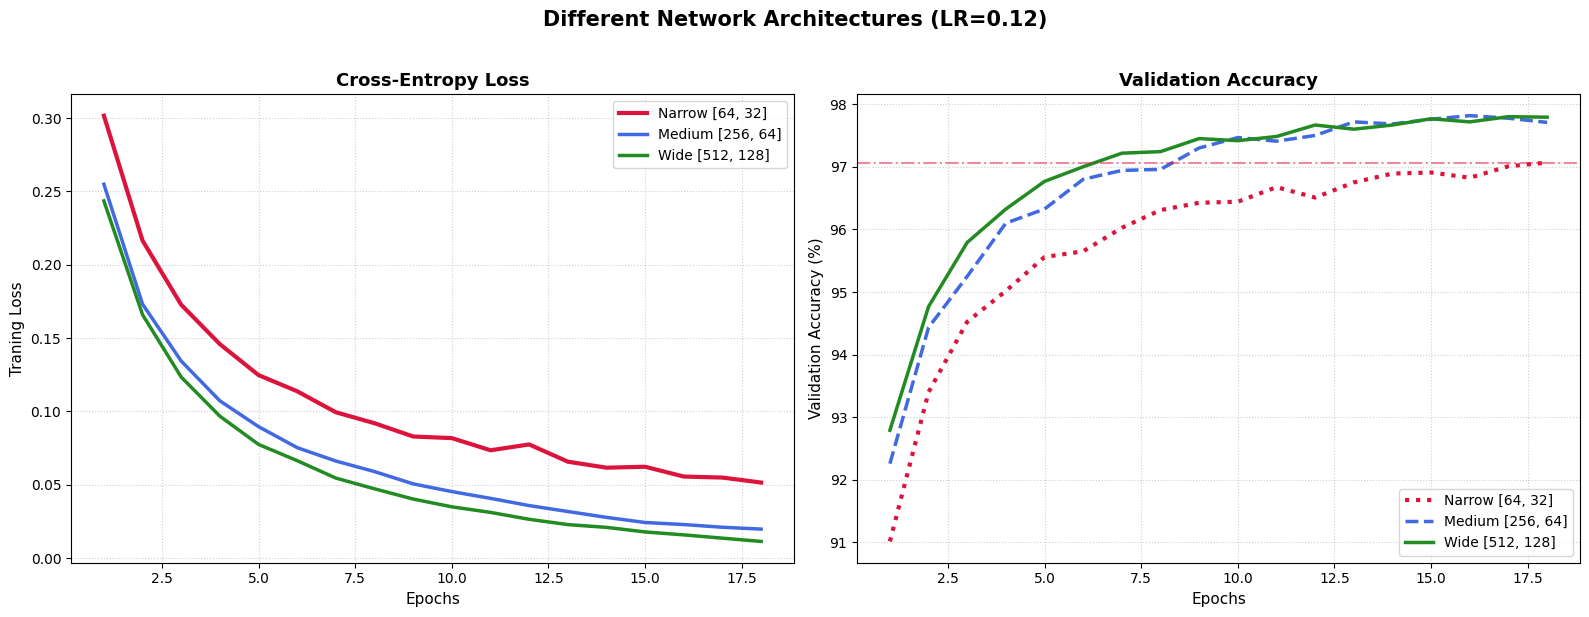

In [11]:
learning_rate = 0.12   
batch_size = 128
epochs = 18            
patience_val = 15      

arch_narrow = [784, 64, 32, 10]
arch_medium = [784, 256, 64, 10]
arch_wide   = [784, 512, 128, 10]
activations_list = ['relu', 'tanh']

epochs_range = range(1, epochs + 1)

# -------------------------------------------------------------
# 1. NARROW ARCHITECTURE TRAINING [784, 64, 32, 10]
# -------------------------------------------------------------
start_time = time.time()
mlp_small = multilayer_perceptron(arch_narrow, activations_list, learning_rate, epochs, batch_size)
mlp_small.fit(X_train, Y_train, X_val, Y_val, patience=patience_val)
time_narrow = time.time() - start_time
print(f"Narrow Architecture [784, 64, 32, 10] Complete in: {time_narrow:.2f} seconds")

# -------------------------------------------------------------
# 2. MEDIUM ARCHITECTURE TRAINING [784, 256, 64, 10]
# -------------------------------------------------------------
start_time = time.time()
mlp_medium = multilayer_perceptron(arch_medium, activations_list, learning_rate, epochs, batch_size)
mlp_medium.fit(X_train, Y_train, X_val, Y_val, patience=patience_val)
time_medium = time.time() - start_time
print(f"Medium Architecture [784, 256, 64, 10] Complete in: {time_medium:.2f} seconds")

# -------------------------------------------------------------
# 3. WIDE ARCHITECTURE TRAINING [784, 512, 128, 10]
# -------------------------------------------------------------
start_time = time.time()
mlp_large = multilayer_perceptron(arch_wide, activations_list, learning_rate, epochs, batch_size)
mlp_large.fit(X_train, Y_train, X_val, Y_val, patience=patience_val)
time_wide = time.time() - start_time
print(f"Wide Architecture [784, 512, 128, 10] Complete in: {time_wide:.2f} seconds")

# =============================================================
# PLOTS
# =============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Cross-Entropy Training Loss Curves ---
ax1.plot(epochs_range, mlp_small.results, color='crimson', linestyle='-', linewidth=3, label=f'Narrow [64, 32]')
ax1.plot(epochs_range, mlp_medium.results, color='royalblue', linestyle='-', linewidth=2.5, label=f'Medium [256, 64]')
ax1.plot(epochs_range, mlp_large.results, color='forestgreen', linestyle='-', linewidth=2.5, label=f'Wide [512, 128]')

ax1.set_title('Cross-Entropy Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Traning Loss', fontsize=11)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: Validation Accuracy & The Hard Learning Wall ---
ax2.plot(epochs_range, mlp_small.val_accuracy, color='crimson', linestyle=':', linewidth=3, label=f'Narrow [64, 32]')
ax2.plot(epochs_range, mlp_medium.val_accuracy, color='royalblue', linestyle='--', linewidth=2.5, label=f'Medium [256, 64]')
ax2.plot(epochs_range, mlp_large.val_accuracy, color='forestgreen', linestyle='-', linewidth=2.5, label=f'Wide [512, 128]')

ax2.set_title('Validation Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=11)
ax2.set_ylabel('Validation Accuracy (%)', fontsize=11)
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.6)

# Overlay the asymptotic capacity barrier of the narrow network
narrow_max = max(mlp_small.val_accuracy)
ax2.axhline(y=narrow_max, color='crimson', linestyle='-.', alpha=0.5, linewidth=1.5)

plt.suptitle(f'Different Network Architectures (LR={learning_rate})', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
mlp = multilayer_perceptron(
    layer_neurons=[784,512,128,10],
    activations=['relu','tanh'],
    learning_rate=0.15,
    epochs=35,
    batch_size=128,
    keep_prob=0.7,
    print_logs= True
    )
mlp.fit(X_train,Y_train,X_val,Y_val,patience=100)


Epoch 01/35 | Train Loss: 0.2171 | Val Loss: 0.2273 | Val Acc: 93.27%
Epoch 02/35 | Train Loss: 0.1424 | Val Loss: 0.1573 | Val Acc: 95.43%
Epoch 03/35 | Train Loss: 0.1043 | Val Loss: 0.1261 | Val Acc: 96.16%
Epoch 04/35 | Train Loss: 0.0812 | Val Loss: 0.1078 | Val Acc: 96.75%
Epoch 05/35 | Train Loss: 0.0681 | Val Loss: 0.0993 | Val Acc: 96.94%
Epoch 06/35 | Train Loss: 0.0574 | Val Loss: 0.0938 | Val Acc: 97.04%
Epoch 07/35 | Train Loss: 0.0491 | Val Loss: 0.0869 | Val Acc: 97.32%
Epoch 08/35 | Train Loss: 0.0406 | Val Loss: 0.0826 | Val Acc: 97.48%
Epoch 09/35 | Train Loss: 0.0338 | Val Loss: 0.0793 | Val Acc: 97.52%
Epoch 10/35 | Train Loss: 0.0298 | Val Loss: 0.0747 | Val Acc: 97.67%
Epoch 11/35 | Train Loss: 0.0270 | Val Loss: 0.0763 | Val Acc: 97.58%
Epoch 12/35 | Train Loss: 0.0235 | Val Loss: 0.0765 | Val Acc: 97.56%
Epoch 13/35 | Train Loss: 0.0212 | Val Loss: 0.0724 | Val Acc: 97.72%
Epoch 14/35 | Train Loss: 0.0168 | Val Loss: 0.0700 | Val Acc: 97.83%
Epoch 15/35 | Train 

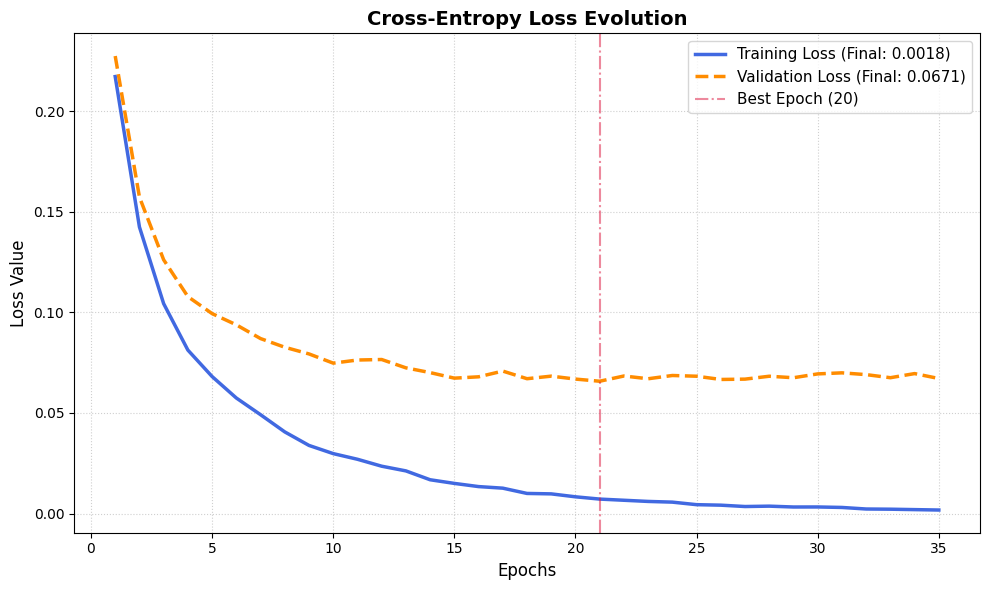

In [13]:
epochs_range = range(1, len(mlp.results) + 1)

plt.figure(figsize=(10, 6))

plt.plot(epochs_range, mlp.results, color='royalblue', linestyle='-', linewidth=2.5, 
         label=f'Training Loss (Final: {mlp.results[-1]:.4f})')

plt.plot(epochs_range, mlp.val_results, color='darkorange', linestyle='--', linewidth=2.5, 
         label=f'Validation Loss (Final: {mlp.val_results[-1]:.4f})')

plt.title('Cross-Entropy Loss Evolution', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)

validation_min_loss = min(mlp.val_results)
best_epoch = mlp.val_results.index(validation_min_loss)
plt.axvline(x=best_epoch + 1, color='crimson', linestyle='-.', alpha=0.5, linewidth=1.5,label=f'Best Epoch ({best_epoch})')

plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [14]:
test_df = pd.read_csv("dataset/mnist_test.csv")
test_df

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
X_test_raw = test_df.drop("label",axis=1).to_numpy()
X_test = X_test_raw / 255.0

In [16]:
Y_test_raw = test_df["label"].to_numpy()

number_of_classes = 10
Y_test = np.eye(number_of_classes)[Y_test_raw] # One-hot encoding 

In [17]:
mlp = multilayer_perceptron(
    layer_neurons=[784,512,128,10],
    activations=['relu','tanh'],
    learning_rate=0.15,
    epochs=30,
    batch_size=128,
    keep_prob=0.7,
    print_logs=True
    )
mlp.fit(X,Y,X_test,Y_test,patience=6)

Epoch 01/30 | Train Loss: 0.2063 | Val Loss: 0.2026 | Val Acc: 94.29%
Epoch 02/30 | Train Loss: 0.1222 | Val Loss: 0.1266 | Val Acc: 96.14%
Epoch 03/30 | Train Loss: 0.0922 | Val Loss: 0.1036 | Val Acc: 96.89%
Epoch 04/30 | Train Loss: 0.0728 | Val Loss: 0.0874 | Val Acc: 97.40%
Epoch 05/30 | Train Loss: 0.0588 | Val Loss: 0.0776 | Val Acc: 97.66%
Epoch 06/30 | Train Loss: 0.0471 | Val Loss: 0.0695 | Val Acc: 97.93%
Epoch 07/30 | Train Loss: 0.0426 | Val Loss: 0.0665 | Val Acc: 98.05%
Epoch 08/30 | Train Loss: 0.0390 | Val Loss: 0.0681 | Val Acc: 97.87%
Epoch 09/30 | Train Loss: 0.0307 | Val Loss: 0.0625 | Val Acc: 98.09%
Epoch 10/30 | Train Loss: 0.0280 | Val Loss: 0.0628 | Val Acc: 98.01%
Epoch 11/30 | Train Loss: 0.0228 | Val Loss: 0.0597 | Val Acc: 98.16%
Epoch 12/30 | Train Loss: 0.0242 | Val Loss: 0.0685 | Val Acc: 97.81%
Epoch 13/30 | Train Loss: 0.0167 | Val Loss: 0.0578 | Val Acc: 98.18%
Epoch 14/30 | Train Loss: 0.0163 | Val Loss: 0.0598 | Val Acc: 98.07%
Epoch 15/30 | Train 

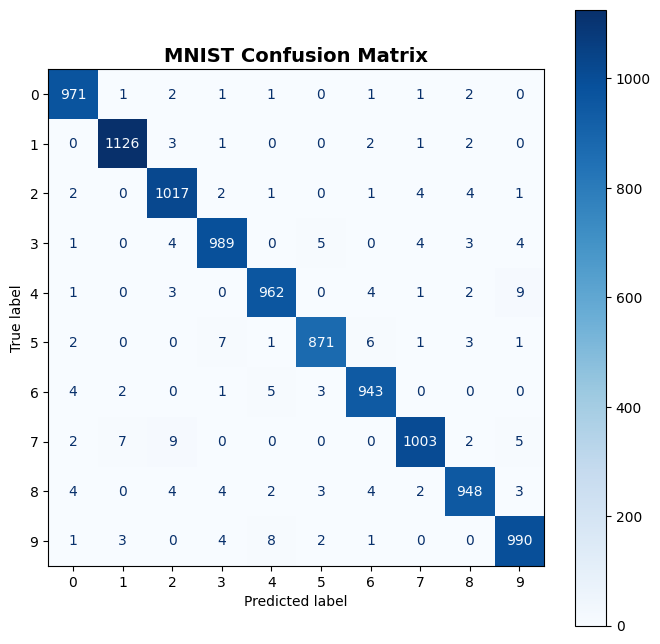

 Test Accuracy: 98.20%
Total misclassified images in validation set: 180 out of 10000


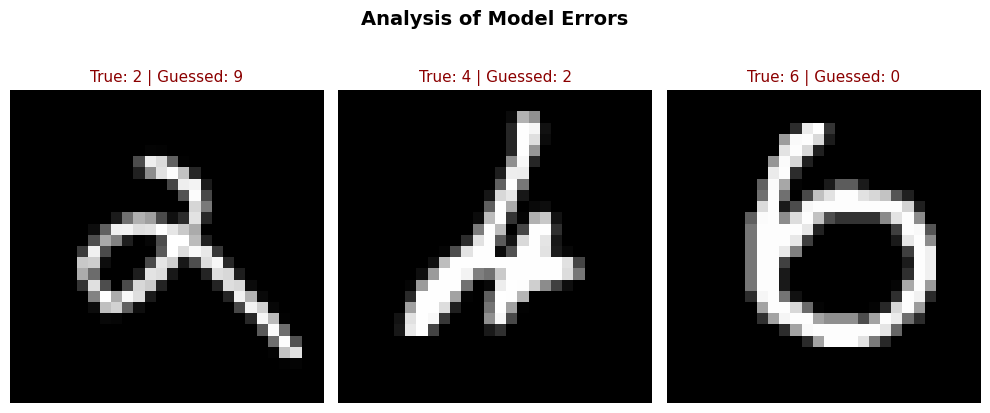

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

test_predictions = mlp.feed_forward(X_test)
pred_digits = np.argmax(test_predictions, axis=1)
true_digits = np.argmax(Y_test, axis=1)

cm = confusion_matrix(true_digits, pred_digits)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('MNIST Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

test_accuracy = np.mean(pred_digits == true_digits) * 100
print(f" Test Accuracy: {test_accuracy:.2f}%")
misclassified_indices = np.where(pred_digits != true_digits)[0]
print(f"Total misclassified images in validation set: {len(misclassified_indices)} out of {pred_digits.shape[0]}")

plt.figure(figsize=(10, 4))
for i, idx in enumerate(misclassified_indices[:3]):
    plt.subplot(1, 3, i + 1)
    img = X_test[idx].reshape(28, 28) 
    
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_digits[idx]} | Guessed: {pred_digits[idx]}", fontsize=11, color='darkred')
    plt.axis('off')

plt.suptitle('Analysis of Model Errors', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [19]:
def show_class_samples(X, Y, target_class, num_samples=5):

    labels = np.argmax(Y, axis=1)

    class_indices = np.where(labels == target_class)[0]
    
    selected_indices = np.random.choice(class_indices, size=min(num_samples, len(class_indices)), replace=False)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(2 * num_samples, 2.5))
    
    for ax, idx in zip(axes, selected_indices):
        img = X[idx].reshape(28, 28)
        
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Idx: {idx}", fontsize=10)
        ax.axis('off')
        
    plt.suptitle(f"Random Samples from Class: {target_class}", fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

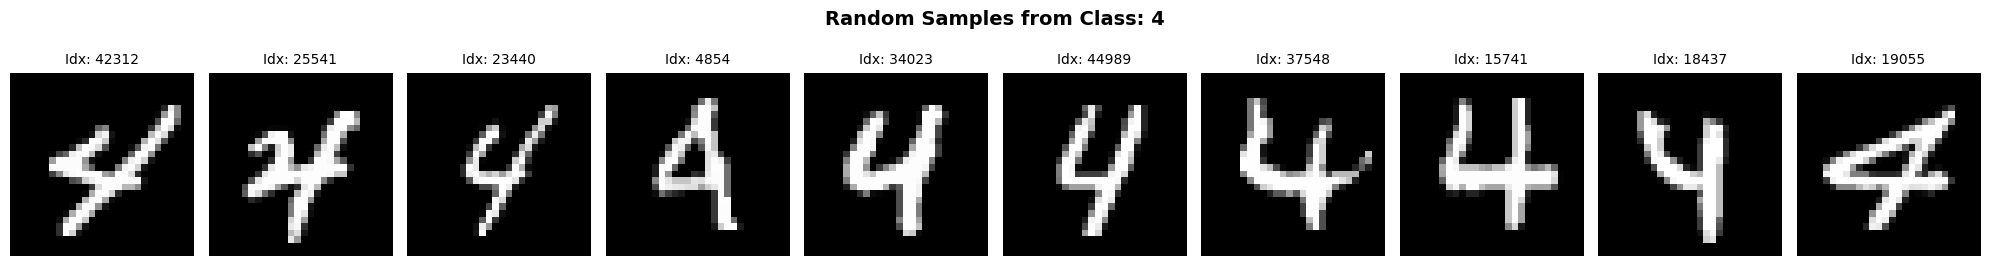

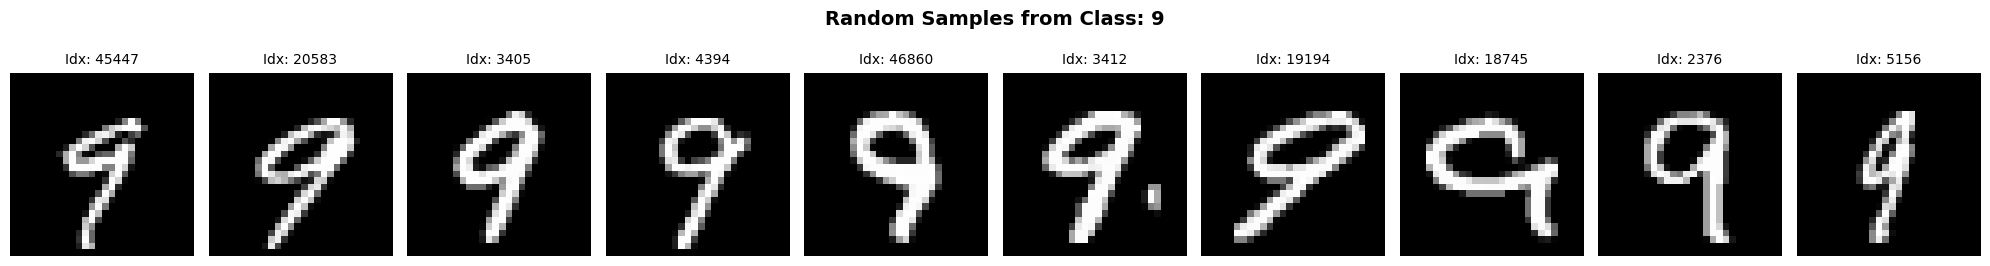

In [20]:
np.random.seed(42)
show_class_samples(X_train,Y_train,4,10)
show_class_samples(X_train,Y_train,9,10)

In [21]:
mlp.save_model("normal_mlp")

saved the model in normal_mlp.npz


In [22]:
class multilayer_perceptron_AdamOpt:
    def __init__(self, layer_neurons, activations, learning_rate, epochs, batch_size, keep_prob=0.8, beta1=0.9, beta2=0.999):
        self.layers_n = layer_neurons
        if activations[-1] != 'softmax':
            self.activations = activations + ['softmax']
        else:
            self.activations = activations
            
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.keep_prob = keep_prob
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = 1e-8
        self.t = 0

        self.results = []
        self.val_results = []       
        self.accuracy = []
        self.val_accuracy = []

        # Initialize Weights and Biases
        self.W = []
        self.b = []
        for i in range(len(layer_neurons)-1):
            n_in = layer_neurons[i]
            n_out = layer_neurons[i+1]
            
            if self.activations[i] == 'relu':
                scale = np.sqrt(2.0 / n_in)  # He Initialization
            else:
                scale = np.sqrt(1.0 / n_in)  # Xavier/Glorot Initialization
                
            self.W.append(np.random.randn(n_in, n_out) * scale)
            self.b.append(np.zeros((1, n_out)))
            
        # Adam Momentum Vectors
        self.m_W = [np.zeros_like(w) for w in self.W]
        self.v_W = [np.zeros_like(w) for w in self.W]
        self.m_b = [np.zeros_like(bias) for bias in self.b]
        self.v_b = [np.zeros_like(bias) for bias in self.b]
        
        self.activation_funcs = {'relu': self.ReLU, 'tanh': self.tanh, 'softmax': self.softmax}
        self.activation_derivatives = {'relu': self.ReLU_derivative, 'tanh': self.tanh_derivative}

    # --- Activation Functions ---
    def ReLU(self, X): 
        return np.maximum(0, X)
    
    def ReLU_derivative(self, A): 
        return (A > 0) * 1.0

    def tanh(self, X):
        a = np.exp(np.clip(X, -500, 500))
        b = np.exp(-np.clip(X, -500, 500))
        return (a - b) / (a + b)

    def tanh_derivative(self, X): 
        A_clean = self.tanh(X)
        return 1.0 - A_clean**2 

    def softmax(self, X):
        row_maxes = np.max(X, axis=1, keepdims=True)
        shifted_X = X - row_maxes
        exp_X = np.exp(shifted_X)
        return exp_X / np.sum(exp_X, axis=1, keepdims=True)

    # --- Forward Propagation ---
    def feed_forward(self, X, training=False):
        self.A = [X]
        self.Z = []
        self.masks = []  
        
        for i in range(len(self.W)):
            z = np.dot(self.A[i], self.W[i]) + self.b[i]
            self.Z.append(z)
            a = self.activation_funcs[self.activations[i]](z)
            
            if training and i < len(self.W) - 1:
                mask = (np.random.rand(*a.shape) < self.keep_prob)
                a = (a * mask) / self.keep_prob
                self.masks.append(mask)
            else:
                self.masks.append(None)
                
            self.A.append(a)
            
        return self.A[-1]

    def _backpropagate(self, Y):
        total_samples = Y.shape[0]
        
        dW = [None] * len(self.W)
        db = [None] * len(self.b)
        
        dZ = self.A[-1] - Y
        
        for i in reversed(range(len(self.W))):
            dW[i] = np.dot(self.A[i].T, dZ) / total_samples
            db[i] = np.sum(dZ, axis=0, keepdims=True) / total_samples
            
            if i > 0:
                act_prev = self.activations[i-1]
                derivative = self.activation_derivatives[act_prev](self.Z[i-1])
                dZ = np.dot(dZ, self.W[i].T) * derivative
                
                if self.masks[i-1] is not None:
                    dZ = (dZ * self.masks[i-1]) / self.keep_prob
        
        self.t += 1  
        
        for i in range(len(self.W)):
            # Update Weight Moments
            self.m_W[i] = self.beta1 * self.m_W[i] + (1 - self.beta1) * dW[i]
            self.v_W[i] = self.beta2 * self.v_W[i] + (1 - self.beta2) * (dW[i] ** 2)
            m_W_corrected = self.m_W[i] / (1 - self.beta1 ** self.t)
            v_W_corrected = self.v_W[i] / (1 - self.beta2 ** self.t)
            self.W[i] -= self.lr * m_W_corrected / (np.sqrt(v_W_corrected) + self.epsilon)
            
            # Update Bias Moments
            self.m_b[i] = self.beta1 * self.m_b[i] + (1 - self.beta1) * db[i]
            self.v_b[i] = self.beta2 * self.v_b[i] + (1 - self.beta2) * (db[i] ** 2)
            m_b_corrected = self.m_b[i] / (1 - self.beta1 ** self.t)
            v_b_corrected = self.v_b[i] / (1 - self.beta2 ** self.t)
            self.b[i] -= self.lr * m_b_corrected / (np.sqrt(v_b_corrected) + self.epsilon)
    
    def compute_loss(self, Y_pred, Y_true):
        epsilon = 1e-15
        Y_pred = np.clip(Y_pred, epsilon, 1 - epsilon)
        return -np.sum(Y_true * np.log(Y_pred)) / Y_true.shape[0]
    
    def save_model(self, filename="fully_trained_mlp"):    
        if not filename.endswith('.npz'):
            filename = filename + ".npz"

        config = np.array([
            self.lr,
            self.batch_size,
            self.keep_prob
        ])
        
        # Create an explicit object array to hold the mismatched bias shapes safely
        b_container = np.empty(len(self.b), dtype=object)
        for idx, bias in enumerate(self.b):
            b_container[idx] = bias

        np.savez_compressed(
            filename, 
            layers_n=np.array(self.layers_n),
            activations=np.array(self.activations),
            config=config,
            b=b_container,  # Pass the safe container instead
            *self.W  
        )
        print(f"saved the model in {filename}")

    @staticmethod
    def load_model(filename="fully_trained_mlp.npz"):
        if not filename.endswith('.npz'):
            filename = filename + ".npz"

        with np.load(filename, allow_pickle=True) as data:
            layers_n = data['layers_n'].tolist()
            activations = data['activations'].tolist()
            config = data['config']
            
            model = multilayer_perceptron(
                layer_neurons=layers_n,
                activations=activations,
                learning_rate=float(config[0]),
                epochs=10,
                batch_size=int(config[1]),
                keep_prob=float(config[2])
            )
            
            num_layers = len(layers_n) - 1
            model.W = [data[f'arr_{i}'] for i in range(num_layers)]
            model.b = list(data['b'])
        
        return model

    def fit(self, X, Y, X_val, Y_val, patience=3):
        total_samples = Y.shape[0]
        indices = np.arange(total_samples)

        best_val_loss = float('inf')
        patience_counter = 0

        for ep in range(self.epochs):
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]

            for i in range(0, total_samples, self.batch_size):
                X_batch = X_shuffled[i : i + self.batch_size]
                Y_batch = Y_shuffled[i : i + self.batch_size]
                
                self.feed_forward(X_batch, training=True)
                self._backpropagate(Y_batch)            

            full_train_pred = self.feed_forward(X, training=False)
            train_loss = self.compute_loss(full_train_pred, Y)
            train_acc = np.mean(np.argmax(full_train_pred, axis=1) == np.argmax(Y, axis=1)) * 100
            
            self.results.append(train_loss)
            self.accuracy.append(train_acc)
            
            val_loss, val_acc = 0.0, 0.0
            if len(Y_val) > 0:
                full_val_pred = self.feed_forward(X_val, training=False) 
                val_loss = self.compute_loss(full_val_pred, Y_val)
                val_acc = np.mean(np.argmax(full_val_pred, axis=1) == np.argmax(Y_val, axis=1)) * 100
                
                self.val_results.append(val_loss)
                self.val_accuracy.append(val_acc)

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0 
                else:
                    patience_counter += 1
                    
                if patience_counter >= patience:
                    print(f"\n[Early Stopping] Validation loss has stalled for {patience} epochs. Stopping training safely to prevent overfitting. Best validation loss: {best_val_loss}")
                    break 

            print(f"Epoch {ep+1:02d}/{self.epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

In [23]:
mlp = multilayer_perceptron_AdamOpt(
    layer_neurons=[784,512,128,10],
    activations=['relu','tanh'],
    learning_rate=0.001,
    epochs=10,
    batch_size=128,
    keep_prob=0.7
    )
mlp.fit(X,Y,[],[],patience=10)

Epoch 01/10 | Train Loss: 0.1032 | Val Loss: 0.0000 | Val Acc: 0.00%
Epoch 02/10 | Train Loss: 0.0664 | Val Loss: 0.0000 | Val Acc: 0.00%
Epoch 03/10 | Train Loss: 0.0484 | Val Loss: 0.0000 | Val Acc: 0.00%
Epoch 04/10 | Train Loss: 0.0339 | Val Loss: 0.0000 | Val Acc: 0.00%
Epoch 05/10 | Train Loss: 0.0278 | Val Loss: 0.0000 | Val Acc: 0.00%
Epoch 06/10 | Train Loss: 0.0256 | Val Loss: 0.0000 | Val Acc: 0.00%
Epoch 07/10 | Train Loss: 0.0180 | Val Loss: 0.0000 | Val Acc: 0.00%
Epoch 08/10 | Train Loss: 0.0181 | Val Loss: 0.0000 | Val Acc: 0.00%
Epoch 09/10 | Train Loss: 0.0135 | Val Loss: 0.0000 | Val Acc: 0.00%
Epoch 10/10 | Train Loss: 0.0111 | Val Loss: 0.0000 | Val Acc: 0.00%


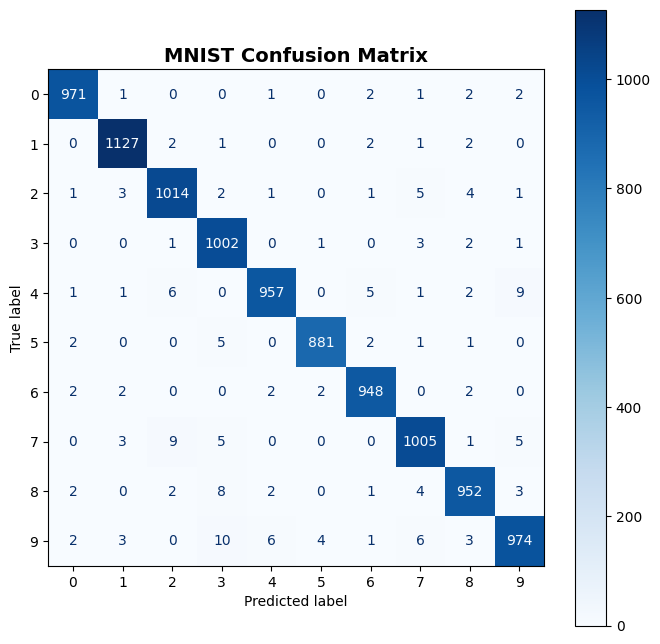

 Test Accuracy: 98.31%


In [24]:
test_predictions = mlp.feed_forward(X_test)
pred_digits = np.argmax(test_predictions, axis=1)
true_digits = np.argmax(Y_test, axis=1)

cm = confusion_matrix(true_digits, pred_digits)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('MNIST Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

test_accuracy = np.mean(pred_digits == true_digits) * 100
print(f" Test Accuracy: {test_accuracy:.2f}%")

In [25]:
mlp.save_model("adam_mlp")

saved the model in adam_mlp.npz


In [27]:
cpy_model = multilayer_perceptron_AdamOpt.load_model("adam_mlp.npz")

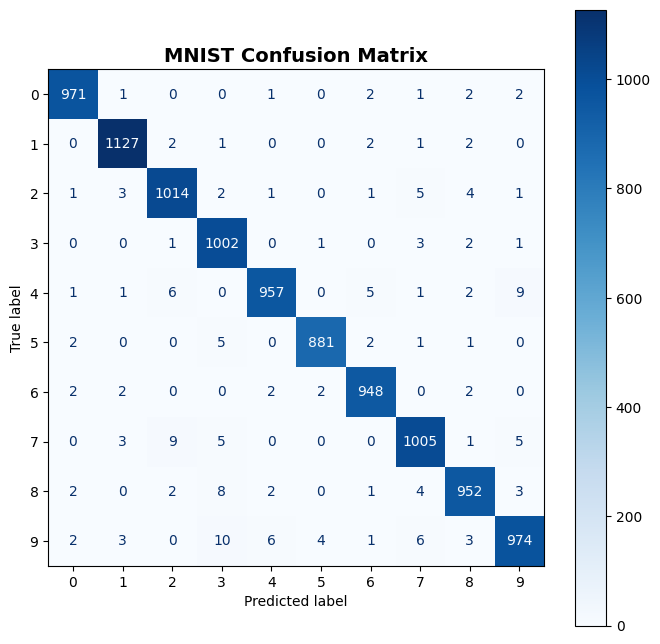

 Test Accuracy: 98.31%


In [28]:
test_predictions = cpy_model.feed_forward(X_test)
pred_digits = np.argmax(test_predictions, axis=1)
true_digits = np.argmax(Y_test, axis=1)

cm = confusion_matrix(true_digits, pred_digits)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('MNIST Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

test_accuracy = np.mean(pred_digits == true_digits) * 100
print(f" Test Accuracy: {test_accuracy:.2f}%")